<a href="https://colab.research.google.com/github/LIBY70/Data-Analysis/blob/main/ida_week5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab5: 데이터 시각화

본 실습 자료는 『처음 시작하는 파이썬 데이터 분석』 (안기수, 생능출판사)을 참고하여 제작되었습니다.


 '+' 붙은 애들은 시험에 안나옴

## 0. 라이브러리 불러오기

| 라이브러리 | 역할 |
|---|---|
| `matplotlib.pyplot` | Python 시각화의 기반 라이브러리 — 세밀한 커스터마이징 가능 |
| `seaborn` | Matplotlib 위에 구축된 통계 시각화 라이브러리 — 코드가 간결하고 기본 디자인이 깔끔 |
| `pandas .plot()` | DataFrame/Series에서 바로 호출 — 빠른 탐색용으로 편리 |


> Seaborn과 pandas `.plot()`은 모두 Matplotlib을 기반으로 동작

In [ ]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

### 한글 폰트 설정

Matplotlib 기본 설정에는 한글 폰트가 포함되어 있지 않으므로, 한글이 포함된 그래프를 올바르게 표시하려면 별도 폰트 지정 필요

In [ ]:
!apt-get install -y fonts-nanum

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 2 not upgraded.


In [ ]:
import platform

if platform.system() == 'Darwin':       # macOS
    mpl.rc('font', family='AppleGothic')
elif platform.system() == 'Windows':    # Windows
    mpl.rc('font', family='Malgun Gothic')
else:                                   # Linux / Colab
    import subprocess, matplotlib.font_manager as fm
    fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')
    mpl.rc('font', family='NanumGothic')

mpl.rc('axes', unicode_minus=False)     # 마이너스 기호 깨짐 방지
print('폰트 설정 완료:', mpl.rcParams['font.family'])

폰트 설정 완료: ['NanumGothic']


In [ ]:
# data.zip 압축 해제 시 한글 깨짐 방지
!unzip -O cp949 data.zip -d .
!rm -rf __MACOSX

Archive:  data.zip
   creating: ./data/
  inflating: ./data/2016-2023_경찰청_보이스피싱_현황.csv  
   creating: ./__MACOSX/
   creating: ./__MACOSX/data/
  inflating: ./__MACOSX/data/._2016-2023_경찰청_보이스피싱_현황.csv  
  inflating: ./data/2024년서울시_하수처리장_코로나바이러스농도.xlsx  
  inflating: ./__MACOSX/data/._2024년서울시_하수처리장_코로나바이러스농도.xlsx  
  inflating: ./data/1999-2023_ghgs.csv  
  inflating: ./__MACOSX/data/._1999-2023_ghgs.csv  
  inflating: ./data/2023_서울시_교통사고.xlsx  
  inflating: ./__MACOSX/data/._2023_서울시_교통사고.xlsx  
  inflating: ./data/2025_광역시도_인구수.csv  
  inflating: ./__MACOSX/data/._2025_광역시도_인구수.csv  


## 1. 히스토그램 (Histogram)

- **연속형(수치형) 데이터**의 분포를 표현
- 데이터를 구간(bin)으로 나누고 각 구간의 **빈도**를 막대 높이로 표시
- 막대 간 **간격 없음** — 연속적인 값임을 표현
- 분포 형태(대칭·치우침), 이상값 유무 파악에 사용

### 데이터 불러오기: 1999–2023 온실가스 배경농도

`1999-2023_ghgs.csv`: 국립기상과학원 안면도 관측소의 연도별 온실가스 농도 데이터

(`.head()`: 첫 5개 행만 표시)

In [ ]:
df_ghgs = pd.read_csv('data/1999-2023_ghgs.csv')
df_ghgs.head()

,지점,시간,CO2_ppm,CH4_ppm,N2O_ppm,CFC11_ppm,CFC12_ppm,CFC113_ppm,SF6_ppm
0,안면도,1999-01-01,373.1,NaN,NaN,NaN,NaN,NaN,NaN
1,안면도,1999-02-01,374.0,NaN,315.2,266.9,534.1,NaN,NaN
2,안면도,1999-03-01,374.9,NaN,314.6,267.5,535.1,NaN,NaN
3,안면도,1999-04-01,375.1,1869.0,314.2,266.7,534.7,NaN,NaN
4,안면도,1999-05-01,374.0,1863.0,314.6,268.6,535.1,NaN,NaN


In [ ]:
df_ghgs.shape, df_ghgs.dtypes

((300, 9),
 지점             object
 시간             object
 CO2_ppm       float64
 CH4_ppm       float64
 N2O_ppm       float64
 CFC11_ppm     float64
 CFC12_ppm     float64
 CFC113_ppm    float64
 SF6_ppm       float64
 dtype: object)

### 히스토그램 — pandas `.plot.hist()`

pandas의 `.plot.hist()` 또는 `.plot(kind='hist')`로 히스토그램 간단하게 그리기 가능

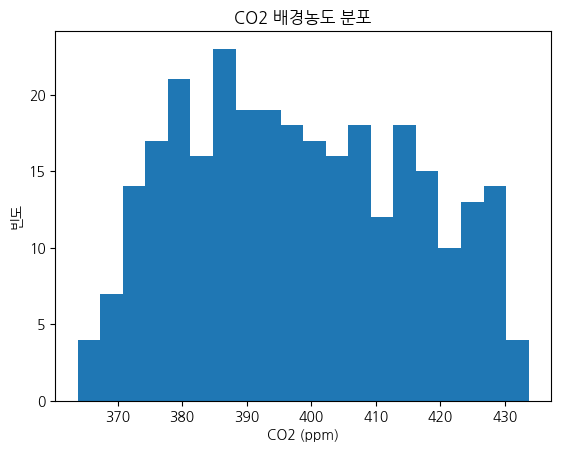

In [ ]:
# CO2 농도 히스토그램 — pandas
df_ghgs['CO2_ppm'].plot(kind='hist', bins=20, title='CO2 배경농도 분포')
plt.xlabel('CO2 (ppm)')
plt.ylabel('빈도')
plt.show() #보여준 후 변수속 데이터 휘발, 터미널에선 이거 없으면 그래프 안나옴.

### 히스토그램 — matplotlib `plt.hist()`

`plt.hist()`를 직접 사용하면 `bins`, `color`, `edgecolor` 등 세밀한 제어 가능

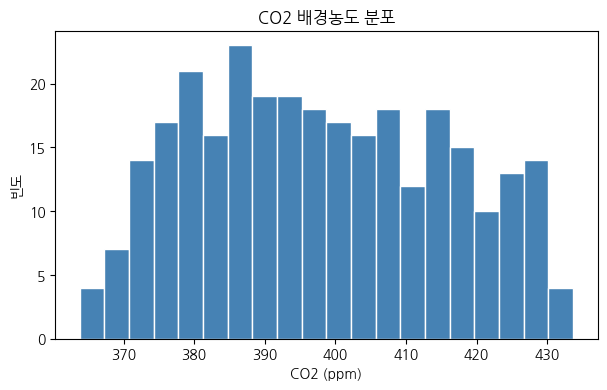

In [ ]:
# CO2 농도 히스토그램 — matplotlib
plt.figure(figsize=(7, 4)) #나 이제 그림그릴거야
plt.hist(df_ghgs['CO2_ppm'].dropna(), bins=20, color='steelblue', edgecolor='white')
plt.xlabel('CO2 (ppm)')
plt.ylabel('빈도')
plt.title('CO2 배경농도 분포')
plt.show()

### 히스토그램 — seaborn `sns.histplot()` (KDE 포함)

`kde=True`를 설정하면 커널 밀도 추정(KDE) 곡선을 함께 표시해 분포의 형태를 더 명확하게 확인 가능

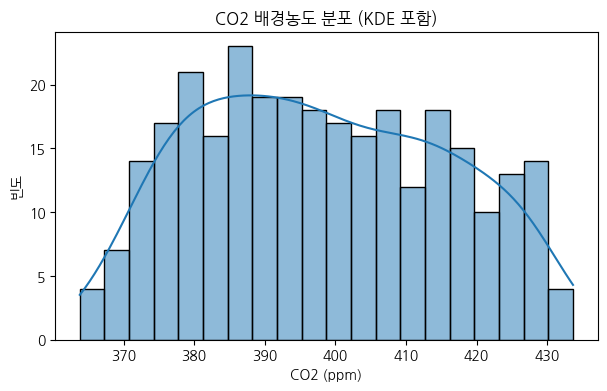

In [ ]:
# CO2 농도 히스토그램 + KDE — seaborn
plt.figure(figsize=(7, 4))
sns.histplot(df_ghgs['CO2_ppm'].dropna(), bins=20, kde=True)
plt.xlabel('CO2 (ppm)')
plt.ylabel('빈도')
plt.title('CO2 배경농도 분포 (KDE 포함)')
plt.show()

### 여러 변수의 히스토그램 한 번에: `subplots=True`

`DataFrame.plot.hist(subplots=True)`를 사용하면 각 열의 히스토그램을 subplot으로 한꺼번에 확인 가능

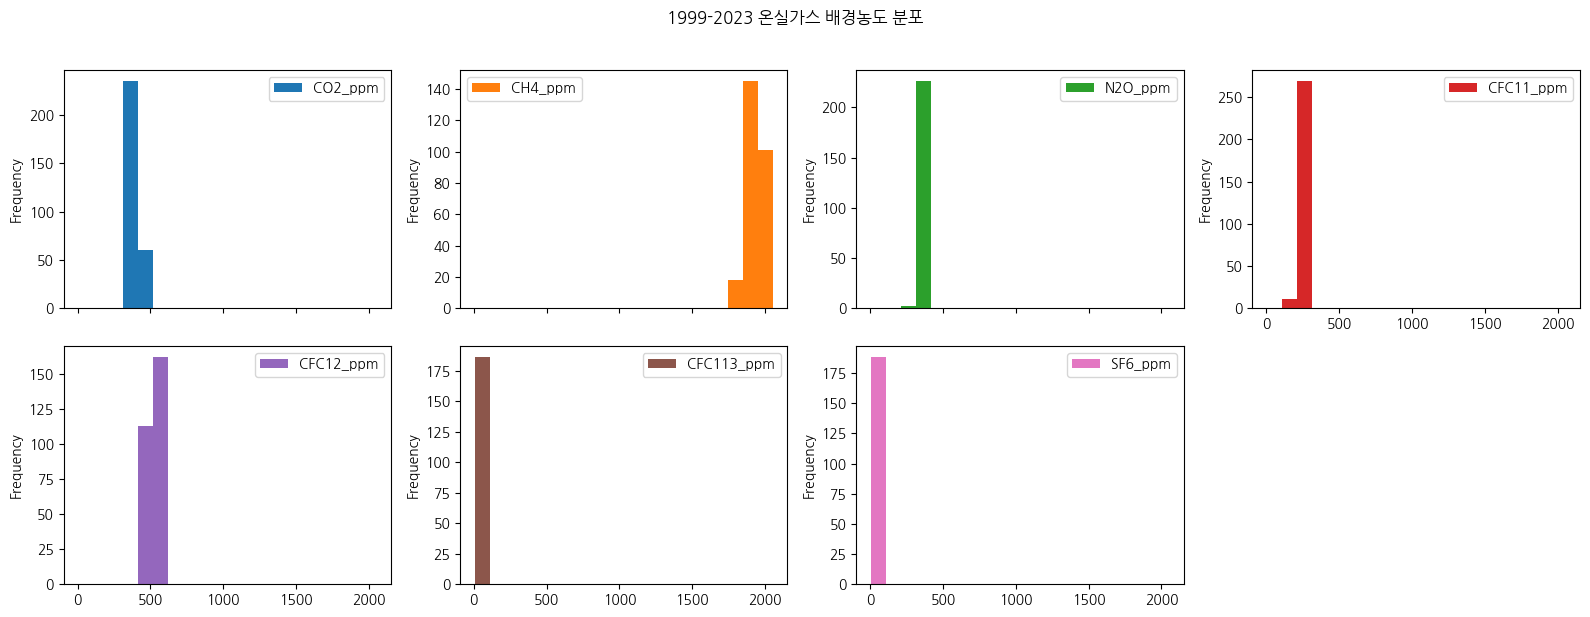

In [ ]:
# 온실가스 7개 변수 히스토그램 서브플롯 — pandas
df_ghgs.iloc[:, 2:].plot.hist(subplots=True, layout=(2, 4), figsize=(16, 6), bins=20)
plt.suptitle('1999-2023 온실가스 배경농도 분포', y=1.02)
plt.tight_layout()
plt.show()

## 2. 막대그래프 (Bar Chart)

- **범주형 데이터**의 빈도나 크기를 비교
- 막대 간 **간격 있음** — 범주(category) 이름이 X축
- 순서를 의도에 따라 정렬 가능

> **히스토그램 vs 막대그래프**: 히스토그램은 연속형(간격 없음), 막대그래프는 범주형(간격 있음)

### 데이터 불러오기: 2025 광역시도 인구수

In [ ]:
df_pop = pd.read_csv('data/2025_광역시도_인구수.csv')
df_pop = df_pop.iloc[1:, :]   # 첫 행(전국 합계) 제외
df_pop.head()

,행정기관,총인구수,세대수,세대당 인구,남자 인구수,여자 인구수,남여 비율
1,서울특별시,9330658,4482949,2.08,4504432,4826226,0.93
2,부산광역시,3263891,1569695,2.08,1588357,1675534,0.95
3,대구광역시,2363281,1104490,2.14,1159235,1204046,0.96
4,인천광역시,3023649,1375788,2.20,1510615,1513034,1.00
5,광주광역시,1407097,657716,2.14,694532,712565,0.97


### 막대그래프 — pandas `.plot.bar()`

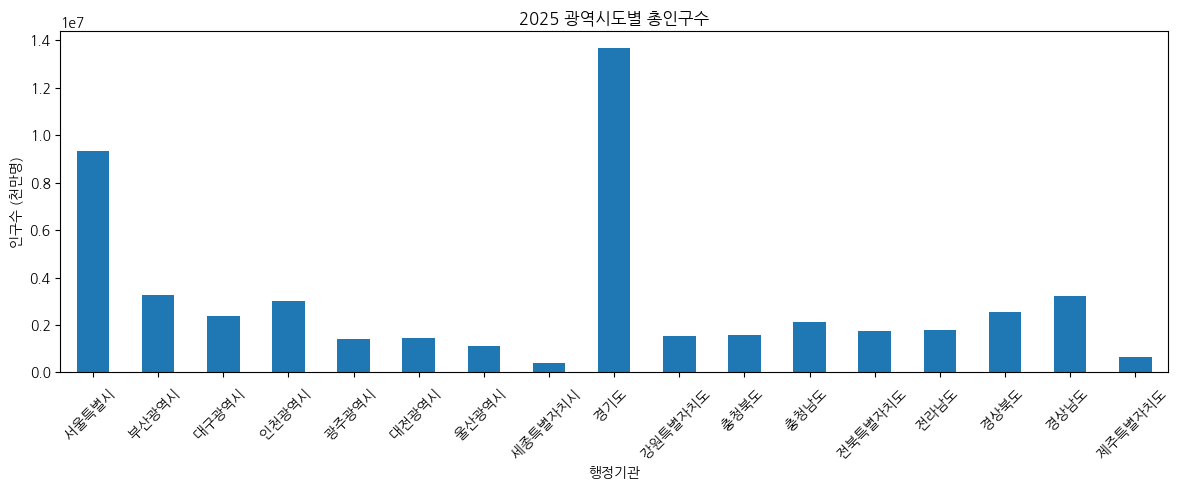

In [ ]:
# 광역시도별 총인구수 막대그래프 — pandas
df_pop.plot.bar(x='행정기관', y='총인구수', rot=45, figsize=(12, 5),
                title='2025 광역시도별 총인구수', legend=False)
plt.ylabel('인구수 (천만명)')
plt.tight_layout()
plt.show()

### 데이터 불러오기: 2023 서울시 교통사고

`value_counts()`로 범주별 빈도를 구한 뒤 막대그래프로 표현

In [ ]:
df_ta = pd.read_excel('data/2023_서울시_교통사고.xlsx')
df_ta.head(3)

,구분번호,발생년월,발생월,요일,시군구,발생구,발생동,사고내용,사망자수,중상자수,...,기상상태,도로형태,가해운전자 차종,가해운전자 성별,가해운전자 연령대,가해운전자 상해정도,피해운전자 차종,피해운전자 성별,피해운전자 연령대,피해운전자 상해정도
0,2023011200100027,2023년 1월,1월,목요일,서울특별시 강동구 상일동,강동구,상일동,사망사고,1,0,...,맑음,단일로 - 기타,승용,남,41-50세,사망,NaN,NaN,NaN,NaN
1,2023011200100044,2023년 1월,1월,목요일,서울특별시 양천구 목동,양천구,목동,사망사고,1,0,...,맑음,단일로 - 기타,자전거,남,65세 이상,사망,승합,남,51-60세,상해없음
2,2023011300100047,2023년 1월,1월,금요일,서울특별시 노원구 상계동,노원구,상계동,사망사고,1,0,...,비,교차로 - 교차로횡단보도내,건설기계,남,51-60세,상해없음,자전거,여,65세 이상,사망


In [ ]:
# 구별 교통사고 발생 건수 빈도 확인
df_ta['발생구'].value_counts().head(10)

,count
발생구,
마포구,13
용산구,11
관악구,10
송파구,10
동대문구,9
강서구,9
노원구,9
성북구,8
도봉구,7


### 빈도 막대그래프 — pandas `.value_counts().plot.bar()`

`value_counts()`의 결과에 바로 `.plot.bar()`를 연결 가능

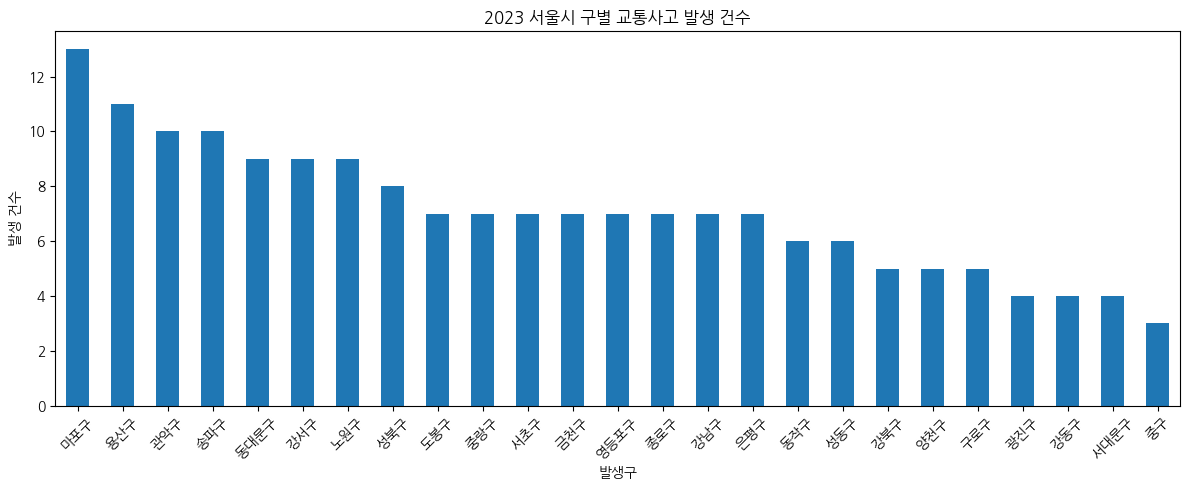

In [ ]:
# 구별 교통사고 발생 건수 막대그래프 — pandas
df_ta['발생구'].value_counts().plot.bar(rot=45, figsize=(12, 5),
                                        title='2023 서울시 구별 교통사고 발생 건수')
plt.ylabel('발생 건수')
plt.tight_layout()
plt.show()

### 가로 막대그래프 — seaborn `sns.countplot()`

`sns.countplot()`은 범주형 열의 빈도를 자동으로 계산하여 막대그래프로 시각화

`y='요일'`로 y축을 지정해 가로 막대그래프 시각화 가능

/tmp/ipykernel_5986/2651377641.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_ta, y='요일', order=day, palette='Blues_r')


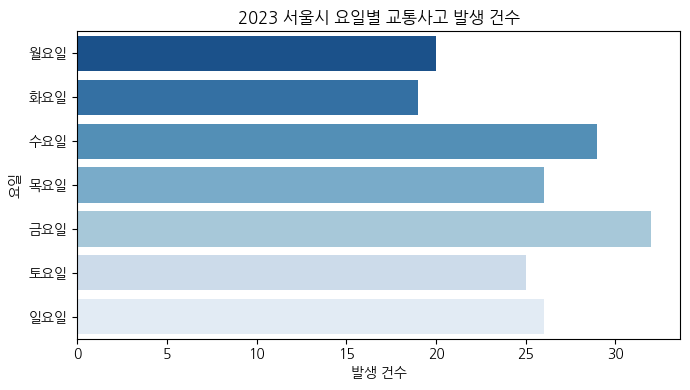

In [ ]:
# 요일별 교통사고 발생 건수 가로 막대그래프 — seaborn
day = ['월요일', '화요일', '수요일', '목요일', '금요일', '토요일', '일요일']
plt.figure(figsize=(7, 4))
sns.countplot(data=df_ta, y='요일', order=day, palette='Blues_r')
plt.xlabel('발생 건수')
plt.title('2023 서울시 요일별 교통사고 발생 건수')
plt.tight_layout()
plt.show()

## 3. 파이차트 (Pie Chart)

- **범주형 데이터의 구성 비율**을 원형으로 표현
- 전체에서 각 범주가 차지하는 상대적 크기 파악에 적합
- 범주 수가 **5개 이하**일 때 가독성이 좋음
- 범주가 많거나 비율 차이가 작으면 막대그래프가 더 효과적

### 파이차트 — pandas `.plot.pie()`

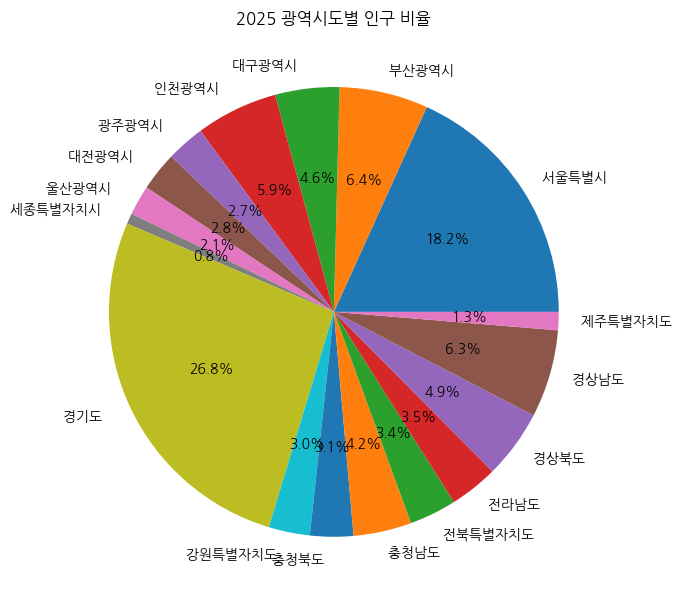

In [ ]:
# 광역시도별 총인구수 파이차트 — pandas
df_pop.plot.pie(
    y='총인구수',
    autopct='%1.1f%%', # 퍼센트찍을려면 특수기호를 찍을려면 두개 찍어야함.
    labels=df_pop['행정기관'],
    legend=False, #법?례
    ylabel='',
    figsize=(7, 7),
    title='2025 광역시도별 인구 비율'
)
plt.tight_layout()
plt.show()

### 파이차트 — matplotlib `plt.pie()`

상위 5개 지역만 뽑아 가독성 높은 파이차트 시각화

`explode`로 특정 조각을 강조하고 `startangle`로 시작 각도를 설정 가능

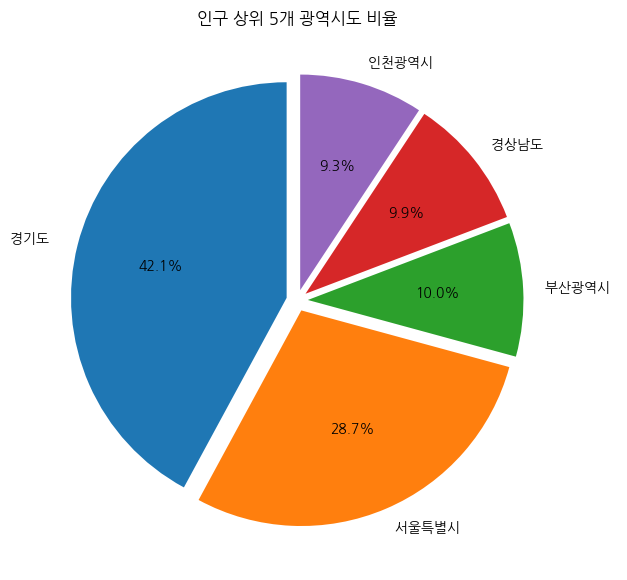

In [ ]:
# 인구 상위 5개 광역시도 파이차트 — matplotlib
df_top5 = df_pop.nlargest(5, '총인구수')

explode = [0.05] * 5
plt.figure(figsize=(7, 7))
plt.pie(
    df_top5['총인구수'],
    labels=df_top5['행정기관'],
    autopct='%1.1f%%',
    explode=explode,# 그래프 떨어트리기
    startangle=90
)
plt.title('인구 상위 5개 광역시도 비율')
plt.show()

## 4. 선 그래프 (Line Chart) — 시계열 데이터

- **시계열 데이터**: 동일한 시간 간격으로 측정된 연속 관측값
- 시간에 따른 **변화 추이·증감·계절성** 파악에 적합
- X축은 반드시 **시간(순서)** — 임의 변경 불가
- 예: 주가, 기온, CO₂ 농도, 물가지수

### 데이터 불러오기: 2016–2023 경찰청 보이스피싱 현황

In [ ]:
df_vf = pd.read_csv('data/2016-2023_경찰청_보이스피싱_현황.csv')
df_vf

,년도,기관사칭형_발생건수,기관사칭형_피해액_억원,기관사칭형_검거건수,기관사칭형_검거인원,대출사기형_발생건수,대출사기형_피해액_억원,대출사기형_검거건수,대출사기형_검거인원
0,2016년,3384,541,3860,5682,13656,927,7526,9884
1,2017년,5685,967,3776,4925,18574,1503,15842,20548
2,2018년,6221,1430,4673,5491,27911,2610,25279,32133
3,2019년,7219,2506,5487,6045,30448,3892,33791,42668
4,2020년,7844,2144,4297,4797,23837,4856,29754,34527
5,2021년,7017,1741,1954,1895,23965,6003,25693,24502
6,2022년,8930,2077,4103,4500,12902,3361,20419,20530
7,2023년,11314,2364,7352,8039,7588,2108,13639,14347


### 선 그래프 — pandas `.plot.line()`

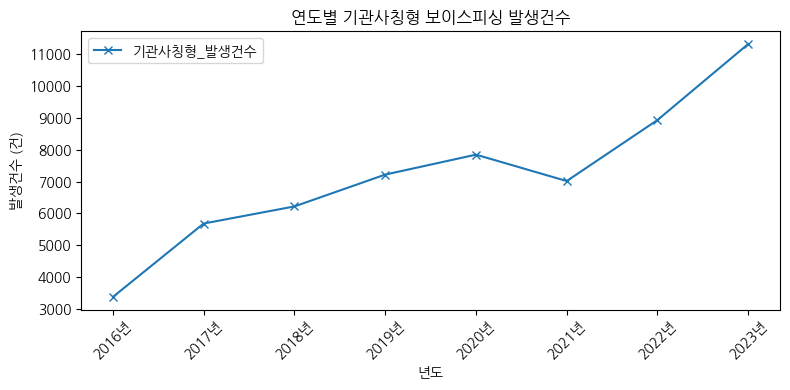

In [ ]:
# 기관사칭형 발생건수 시계열 선 그래프 — pandas
df_vf.plot.line(x='년도', y='기관사칭형_발생건수', marker='x', figsize=(8, 4),
                title='연도별 기관사칭형 보이스피싱 발생건수')
plt.ylabel('발생건수 (건)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

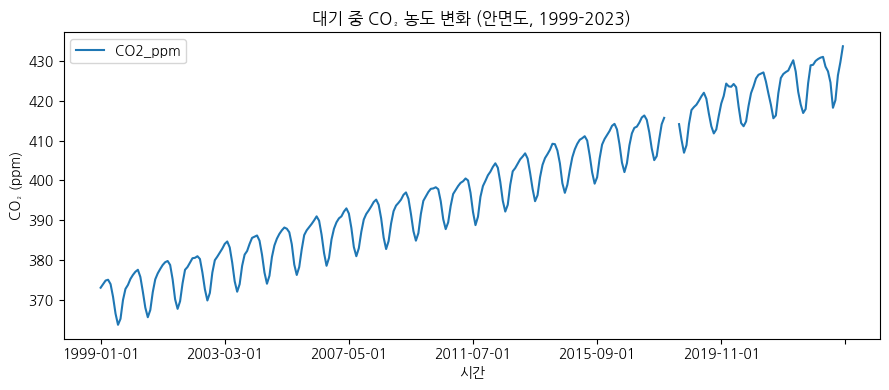

In [ ]:
# CO2 농도 시계열 — pandas 왜 결측치 처리?
df_ghgs.plot.line(x='시간', y='CO2_ppm', figsize=(9, 4),
                  title='대기 중 CO₂ 농도 변화 (안면도, 1999-2023)')
plt.ylabel('CO₂ (ppm)')
plt.tight_layout()
plt.show()

### 여러 계열 선 그래프 — matplotlib `plt.plot()`

기관사칭형과 대출사기형 발생건수를 한 그래프에 비교

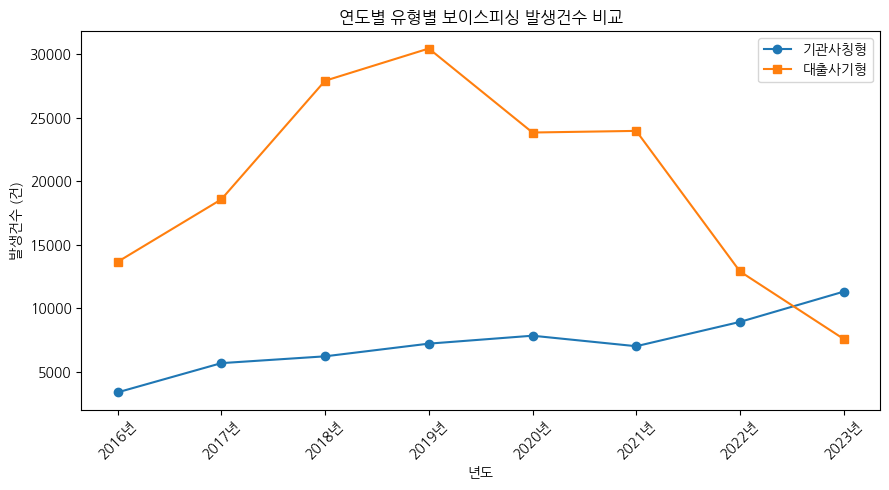

In [ ]:
# 기관사칭형 vs 대출사기형 발생건수 비교 선 그래프 — matplotlib
plt.figure(figsize=(9, 5))
plt.plot(df_vf['년도'], df_vf['기관사칭형_발생건수'], marker='o', label='기관사칭형')
plt.plot(df_vf['년도'], df_vf['대출사기형_발생건수'], marker='s', label='대출사기형')
plt.xlabel('년도')
plt.ylabel('발생건수 (건)')
plt.title('연도별 유형별 보이스피싱 발생건수 비교')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 선 그래프 — seaborn `sns.lineplot()`

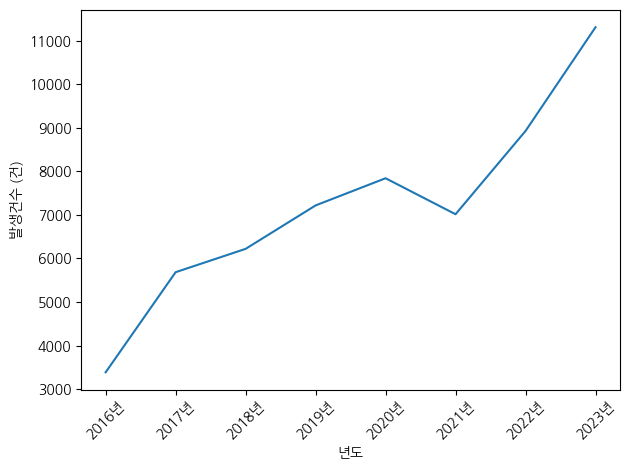

In [ ]:
sns.lineplot(data=df_vf, x='년도', y='기관사칭형_발생건수') #뭘 쓰면 뭐가 나올지 결과값은 알고 있어야함
plt.ylabel('발생건수 (건)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 5. 상자 도형 (Box Plot)

상자 도형이 보여주는 것:

| 요소 | 의미 |
|---|---|
| 상자 아랫면 (Q1) | 하위 25% 지점 |
| 상자 가운데선 (Q2) | 중앙값 (median) |
| 상자 윗면 (Q3) | 하위 75% 지점 |
| 상자 길이 (IQR) | Q3 − Q1, 데이터의 퍼진 정도 |
| 수염(whisker) | Q1−1.5×IQR ~ Q3+1.5×IQR 범위 |
| 점 (outlier) | 수염 밖에 있는 이상치 |

> **장점**: 히스토그램으로는 한 번에 비교하기 어려운 **여러 그룹의 분포**를 나란히 비교 가능

### 데이터 불러오기: 2024 서울시 하수처리장 코로나바이러스 농도

In [ ]:
df_wr = pd.read_excel('data/2024년서울시_하수처리장_코로나바이러스농도.xlsx')
df_wr.head()

,채취_날짜,샘플 채취 주차_1,샘플 채취 주차_2,샘플_채취_지점,c19바이러스_농도
0,2024-01-02,1,1주차,서남 물 재생센터,246453.100994
1,2024-01-02,1,1주차,난지 물 재생센터,68242.156443
2,2024-01-02,1,1주차,탄천 물 재생센터,52544.326514
3,2024-01-02,1,1주차,중랑A 물 재생센터,65538.290177
4,2024-01-02,1,1주차,중랑B 물 재생센터,23026.440802


In [ ]:
# 채취 지점 확인
df_wr['샘플_채취_지점'].unique()

array(['서남 물 재생센터', '난지 물 재생센터', '탄천 물 재생센터', '중랑A 물 재생센터', '중랑B 물 재생센터'],
      dtype=object)

### 상자 도형 — pandas `.boxplot()`

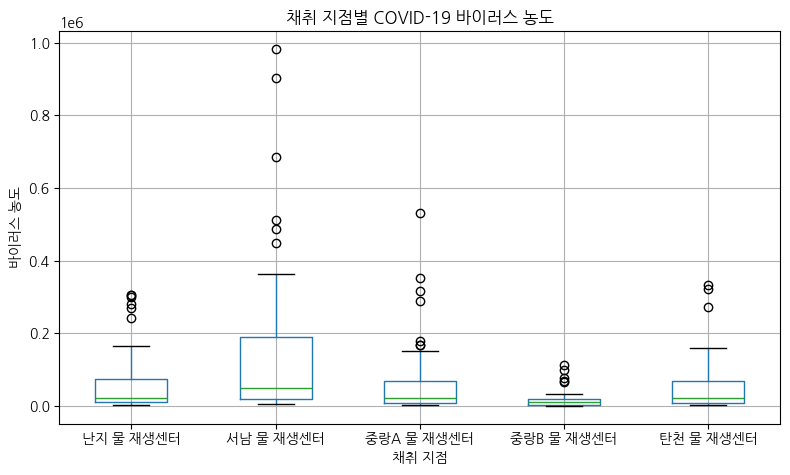

In [ ]:
# 채취 지점별 바이러스 농도 비교 상자 도형 — pandas
df_wr.boxplot(by='샘플_채취_지점', column=['c19바이러스_농도'], figsize=(8, 5))
plt.suptitle('')   # pandas boxplot 자동 생성 제목 제거
plt.title('채취 지점별 COVID-19 바이러스 농도')
plt.xlabel('채취 지점')
plt.ylabel('바이러스 농도')
plt.tight_layout()
plt.show()

### 상자 도형 — seaborn `sns.boxplot()`

seaborn을 사용하면 그룹별 색상, 그리드 등을 더 쉽게 제어 가능

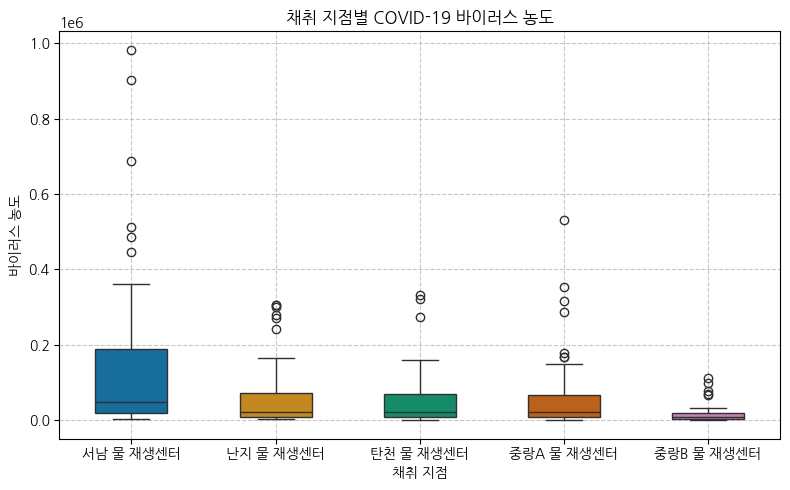

In [ ]:
# 채취 지점별 바이러스 농도 비교 상자 도형 — seaborn <- 한번 더 보기
fig, ax = plt.subplots(figsize=(8, 5)) # subplot ax를 그래프를 담는 리스트로 생각
sns.boxplot(
    data=df_wr, x='샘플_채취_지점', y='c19바이러스_농도',
    hue='샘플_채취_지점', ax=ax, width=0.5, palette='colorblind'
) #hue ?
ax.grid(True, linestyle='--', alpha=0.7)
plt.title('채취 지점별 COVID-19 바이러스 농도')
plt.xlabel('채취 지점')
plt.ylabel('바이러스 농도')
plt.tight_layout()
plt.show()

## 6. 산점도 (Scatter Plot) — 두 변수의 관계

- 두 **수치형 변수**를 X·Y 축에 각각 배치하고 관측값을 점으로 표현
- 양의 상관(r>0): X가 커질수록 Y도 커짐
- 음의 상관(r<0): X가 커질수록 Y는 작아짐
- 상관 없음(r≈0): 두 변수 사이에 패턴 없음

> **주의**: 상관관계 ≠ 인과관계

### 산점도 — pandas `.plot.scatter()`

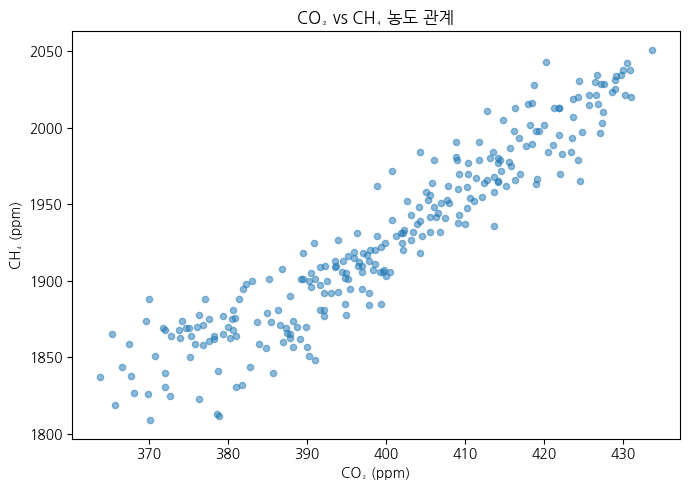

In [ ]:
# CO2 vs CH4 산점도 — pandas alpha = 투명도
df_ghgs.plot.scatter(x='CO2_ppm', y='CH4_ppm', alpha=0.5, figsize=(7, 5),
                     title='CO₂ vs CH₄ 농도 관계')
plt.xlabel('CO₂ (ppm)')
plt.ylabel('CH₄ (ppm)')
plt.tight_layout()
plt.show()

### 산점도 — matplotlib `plt.scatter()`

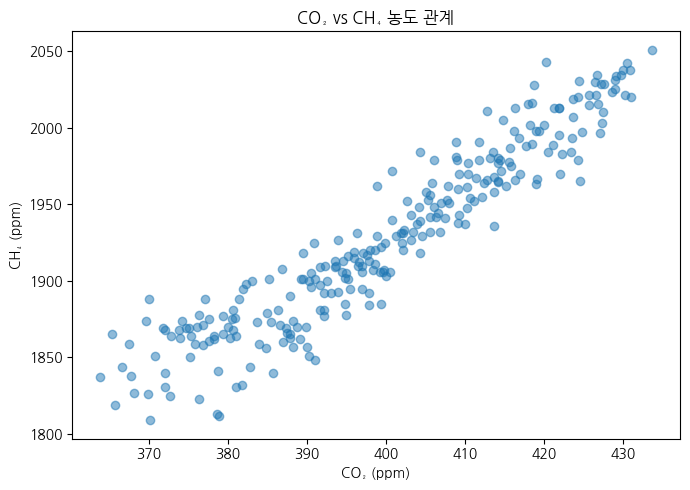

In [ ]:
# CO2 vs CH4 산점도 — matplotlib
plt.figure(figsize=(7, 5))
plt.scatter(df_ghgs['CO2_ppm'], df_ghgs['CH4_ppm'], alpha=0.5)
plt.title('CO₂ vs CH₄ 농도 관계')
plt.xlabel('CO₂ (ppm)')
plt.ylabel('CH₄ (ppm)')
plt.tight_layout()
plt.show()

### 산점도 — seaborn `sns.scatterplot()`

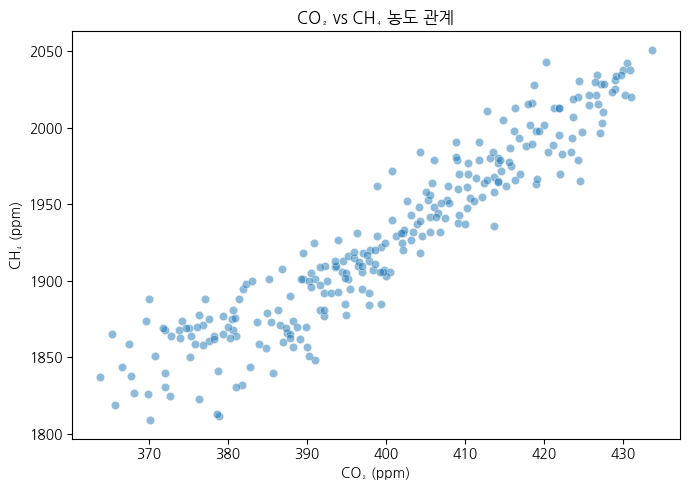

In [ ]:
# CO2 vs CH4 산점도 — seaborn
plt.figure(figsize=(7, 5))
sns.scatterplot(data=df_ghgs, x='CO2_ppm', y='CH4_ppm', alpha=0.5)
plt.title('CO₂ vs CH₄ 농도 관계')
plt.xlabel('CO₂ (ppm)')
plt.ylabel('CH₄ (ppm)')
plt.tight_layout()
plt.show()

### 상자 도형 + 산점도 — `sns.boxplot()` + `sns.stripplot()`

상자 도형 위에 실제 데이터 점을 함께 표시하면 분포의 실제 모습을 더 잘 파악 가능

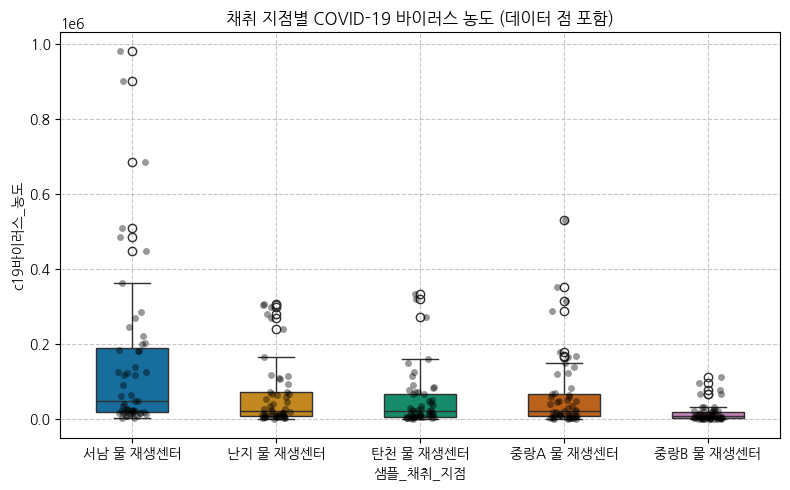

In [ ]:
# 상자 도형 + 개별 데이터 점 (stripplot) — seaborn
np.random.seed(42) # 난수설정 흩어짐 정도를 고정
fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(
    data=df_wr, x='샘플_채취_지점', y='c19바이러스_농도',
    hue='샘플_채취_지점', ax=ax, width=0.5, palette='colorblind'
)
sns.stripplot(
    data=df_wr, x='샘플_채취_지점', y='c19바이러스_농도',
    ax=ax, jitter=True, marker='o', alpha=0.4, color='black'
)
ax.grid(True, linestyle='--', alpha=0.7)
plt.title('채취 지점별 COVID-19 바이러스 농도 (데이터 점 포함)')
plt.tight_layout()
plt.show()

### 산점도 + 회귀선 — seaborn `sns.regplot()`

`sns.regplot()`은 산점도와 선형 회귀선을 자동으로 함께 그려줌

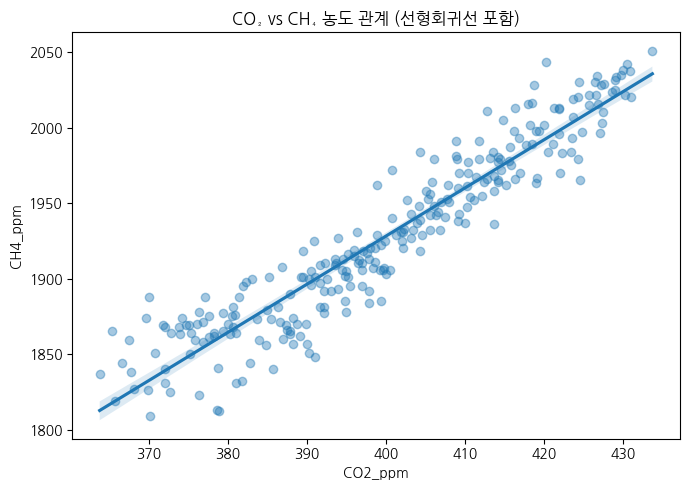

In [ ]:
# CO2 vs CH4 산점도 + 선형회귀선 — seaborn
plt.figure(figsize=(7, 5))
sns.regplot(data=df_ghgs, x='CO2_ppm', y='CH4_ppm', scatter_kws={'alpha': 0.4}) # 함수마다 투명도 지정
plt.title('CO₂ vs CH₄ 농도 관계 (선형회귀선 포함)')
plt.tight_layout()
plt.show()

### + 밀도 기반 산점도 — pandas `.plot.hexbin()`

데이터 포인트가 많아 겹칠 때는 `hexbin`으로 밀도를 색깔로 표현 가능

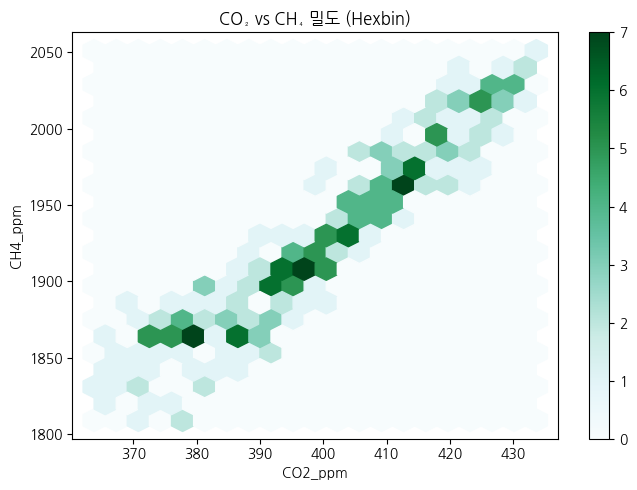

In [ ]:
# CO2 vs CH4 밀도 기반 산점도 (hexbin) — pandas
df_ghgs.plot.hexbin(x='CO2_ppm', y='CH4_ppm', gridsize=20, figsize=(7, 5),
                    title='CO₂ vs CH₄ 밀도 (Hexbin)')
plt.tight_layout()
plt.show()

## 7. 기술통계: 수치로 요약하기

시각화에 앞서 `describe()`로 데이터를 수치로 먼저 요약하는 것이 EDA의 출발점

| 항목 | 의미 |
|---|---|
| `count` | 결측값 제외 데이터 수 |
| `mean` | 평균 |
| `std` | 표준편차 |
| `min` | 최솟값 |
| `25%` | Q1 (1사분위수) |
| `50%` | Q2 (중앙값) |
| `75%` | Q3 (3사분위수) |
| `max` | 최댓값 |

In [ ]:
# 온실가스 전체 기술통계
df_ghgs.describe() #percentile 로 분위수 지정 가능

,CO2_ppm,CH4_ppm,N2O_ppm,CFC11_ppm,CFC12_ppm,CFC113_ppm,SF6_ppm
count,295.000000,264.000000,228.000000,280.000000,275.000000,186.000000,188.000000
mean,398.035288,1928.163182,326.596930,239.687857,520.183273,72.775806,9.063298
std,17.457052,58.762021,7.576833,18.905651,20.076920,3.922259,1.660965
min,363.800000,1809.000000,312.100000,194.700000,480.100000,67.800000,6.000000
25%,383.500000,1877.000000,321.300000,224.150000,500.650000,69.100000,7.875000
50%,396.900000,1921.000000,325.600000,236.100000,524.900000,71.950000,9.200000
75%,412.600000,1977.000000,333.325000,259.550000,539.050000,75.200000,10.300000
max,433.660000,2050.870000,340.000000,270.700000,552.600000,88.500000,12.700000


In [ ]:
# 특정 열만 기술통계
df_ghgs['CO2_ppm'].describe()

,CO2_ppm
count,295.000000
mean,398.035288
std,17.457052
min,363.800000
25%,383.500000
50%,396.900000
75%,412.600000
max,433.660000


In [ ]:
# 분위수 직접 지정: 10%, 50%, 90%
df_ghgs.describe(percentiles=[.1, .5, .9])

,CO2_ppm,CH4_ppm,N2O_ppm,CFC11_ppm,CFC12_ppm,CFC113_ppm,SF6_ppm
count,295.000000,264.000000,228.000000,280.000000,275.000000,186.000000,188.000000
mean,398.035288,1928.163182,326.596930,239.687857,520.183273,72.775806,9.063298
std,17.457052,58.762021,7.576833,18.905651,20.076920,3.922259,1.660965
min,363.800000,1809.000000,312.100000,194.700000,480.100000,67.800000,6.000000
10%,375.240000,1859.000000,315.770000,217.280000,490.800000,68.700000,6.800000
50%,396.900000,1921.000000,325.600000,236.100000,524.900000,71.950000,9.200000
90%,423.460000,2013.140000,337.130000,265.800000,541.600000,78.650000,11.500000
max,433.660000,2050.870000,340.000000,270.700000,552.600000,88.500000,12.700000


### 평균 vs 중앙값

- **평균(mean)**: 이상치에 민감 — 극단값이 있으면 평균이 왜곡됨
- **중앙값(median)**: 이상치에 강건(robust) — 소득·집값 등에 적합

In [ ]:
# 평균 vs 중앙값 비교 — 이상치가 있는 경우 차이가 커짐
col = df_wr['c19바이러스_농도'].dropna()
print(f'평균:   {col.mean():,.1f}')
print(f'중앙값: {col.median():,.1f}')
print(f'표준편차: {col.std():,.1f}')
print(f'IQR: {col.quantile(0.75) - col.quantile(0.25):,.1f}')

평균:   70,768.0
중앙값: 21,071.8
표준편차: 128,006.1
IQR: 62,374.0


## + 8. 상관계수와 히트맵 (Heatmap)

> 이론 수업에서 다루지 않은 추가 실습 내용

- **상관계수(Pearson r)**: 두 수치형 변수의 선형 관계 강도를 −1 ~ +1로 표현
- `DataFrame.corr()`: 모든 수치형 열 쌍의 상관계수 행렬 반환
- `sns.heatmap()`: 상관계수 행렬을 색깔로 시각화

In [ ]:
# CO2와 CH4의 상관계수
r = df_ghgs['CO2_ppm'].corr(df_ghgs['CH4_ppm'])
print(f'CO2 vs CH4 상관계수 (Pearson): {r:.4f}')

CO2 vs CH4 상관계수 (Pearson): 0.9433


In [ ]:
# 온실가스 전체 상관계수 행렬
df_ghgs2 = df_ghgs.iloc[:, 2:]   # CO2~SF6 열만 선택
df_corr = df_ghgs2.corr()
df_corr

,CO2_ppm,CH4_ppm,N2O_ppm,CFC11_ppm,CFC12_ppm,CFC113_ppm,SF6_ppm
CO2_ppm,1.000000,0.943266,0.960828,-0.786477,-0.786410,-0.767033,0.919447
CH4_ppm,0.943266,1.000000,0.911397,-0.704553,-0.743131,-0.735216,0.878096
N2O_ppm,0.960828,0.911397,1.000000,-0.846769,-0.815663,-0.832369,0.959916
CFC11_ppm,-0.786477,-0.704553,-0.846769,1.000000,0.794673,0.455541,-0.367394
CFC12_ppm,-0.786410,-0.743131,-0.815663,0.794673,1.000000,0.613545,-0.663703
CFC113_ppm,-0.767033,-0.735216,-0.832369,0.455541,0.613545,1.000000,-0.795714
SF6_ppm,0.919447,0.878096,0.959916,-0.367394,-0.663703,-0.795714,1.000000


### 상관계수 히트맵 — seaborn `sns.heatmap()`

- `annot=True`: 각 셀에 상관계수 값 표시
- `cmap='coolwarm'`: 양의 상관은 붉은색, 음의 상관은 파란색

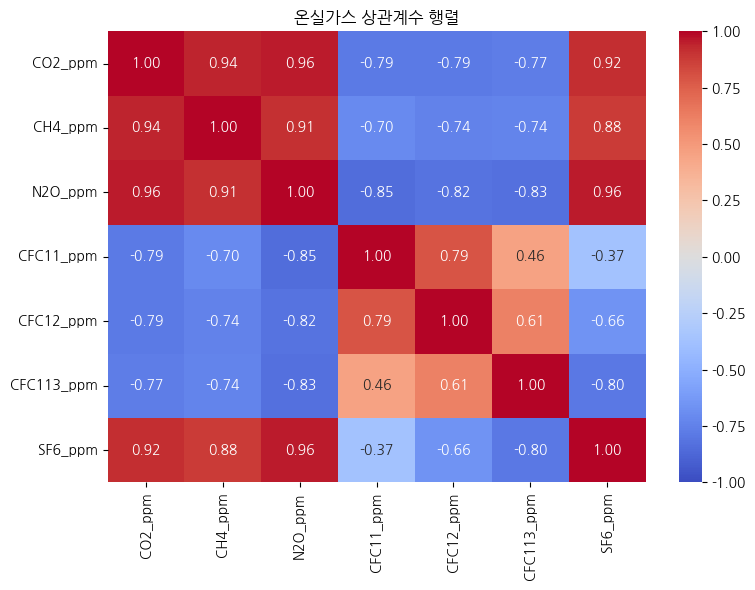

In [ ]:
# 온실가스 상관계수 히트맵 — seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(df_corr, annot=True , fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1) # annot 상관계수 보일지말지
plt.title('온실가스 상관계수 행렬')
plt.tight_layout()
plt.show()

## + 9. 산점도 행렬 (Scatter Matrix)

> 이론 수업에서 다루지 않은 추가 실습 내용

- 여러 변수 간의 관계를 한 번에 확인하는 그래프
- 대각선: 각 변수의 분포 (히스토그램 또는 KDE)
- 비대각선: 두 변수 간의 산점도

### 산점도 행렬 — pandas `scatter_matrix()`

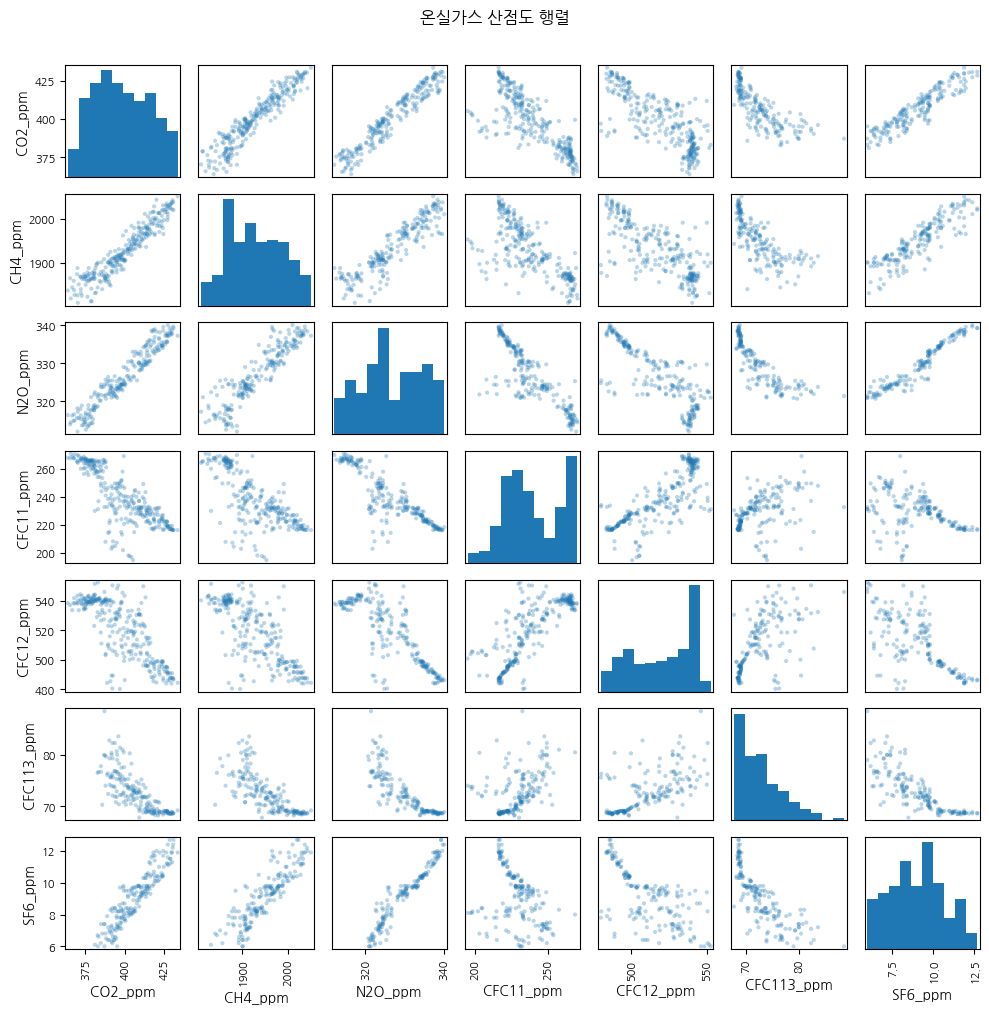

In [ ]:
# 온실가스 산점도 행렬 — pandas
from pandas.plotting import scatter_matrix

scatter_matrix(df_ghgs2, figsize=(10, 10), alpha=0.3, diagonal='hist') #대각선에는 히스토그램 (diagonal)
plt.suptitle('온실가스 산점도 행렬', y=1.01)
plt.tight_layout()
plt.show()

### 산점도 행렬 + 회귀선 — seaborn `sns.pairplot()`

- `diag_kind='kde'`: 대각선에 KDE 곡선 표시
- `kind='reg'`: 비대각선에 선형 회귀선 추가

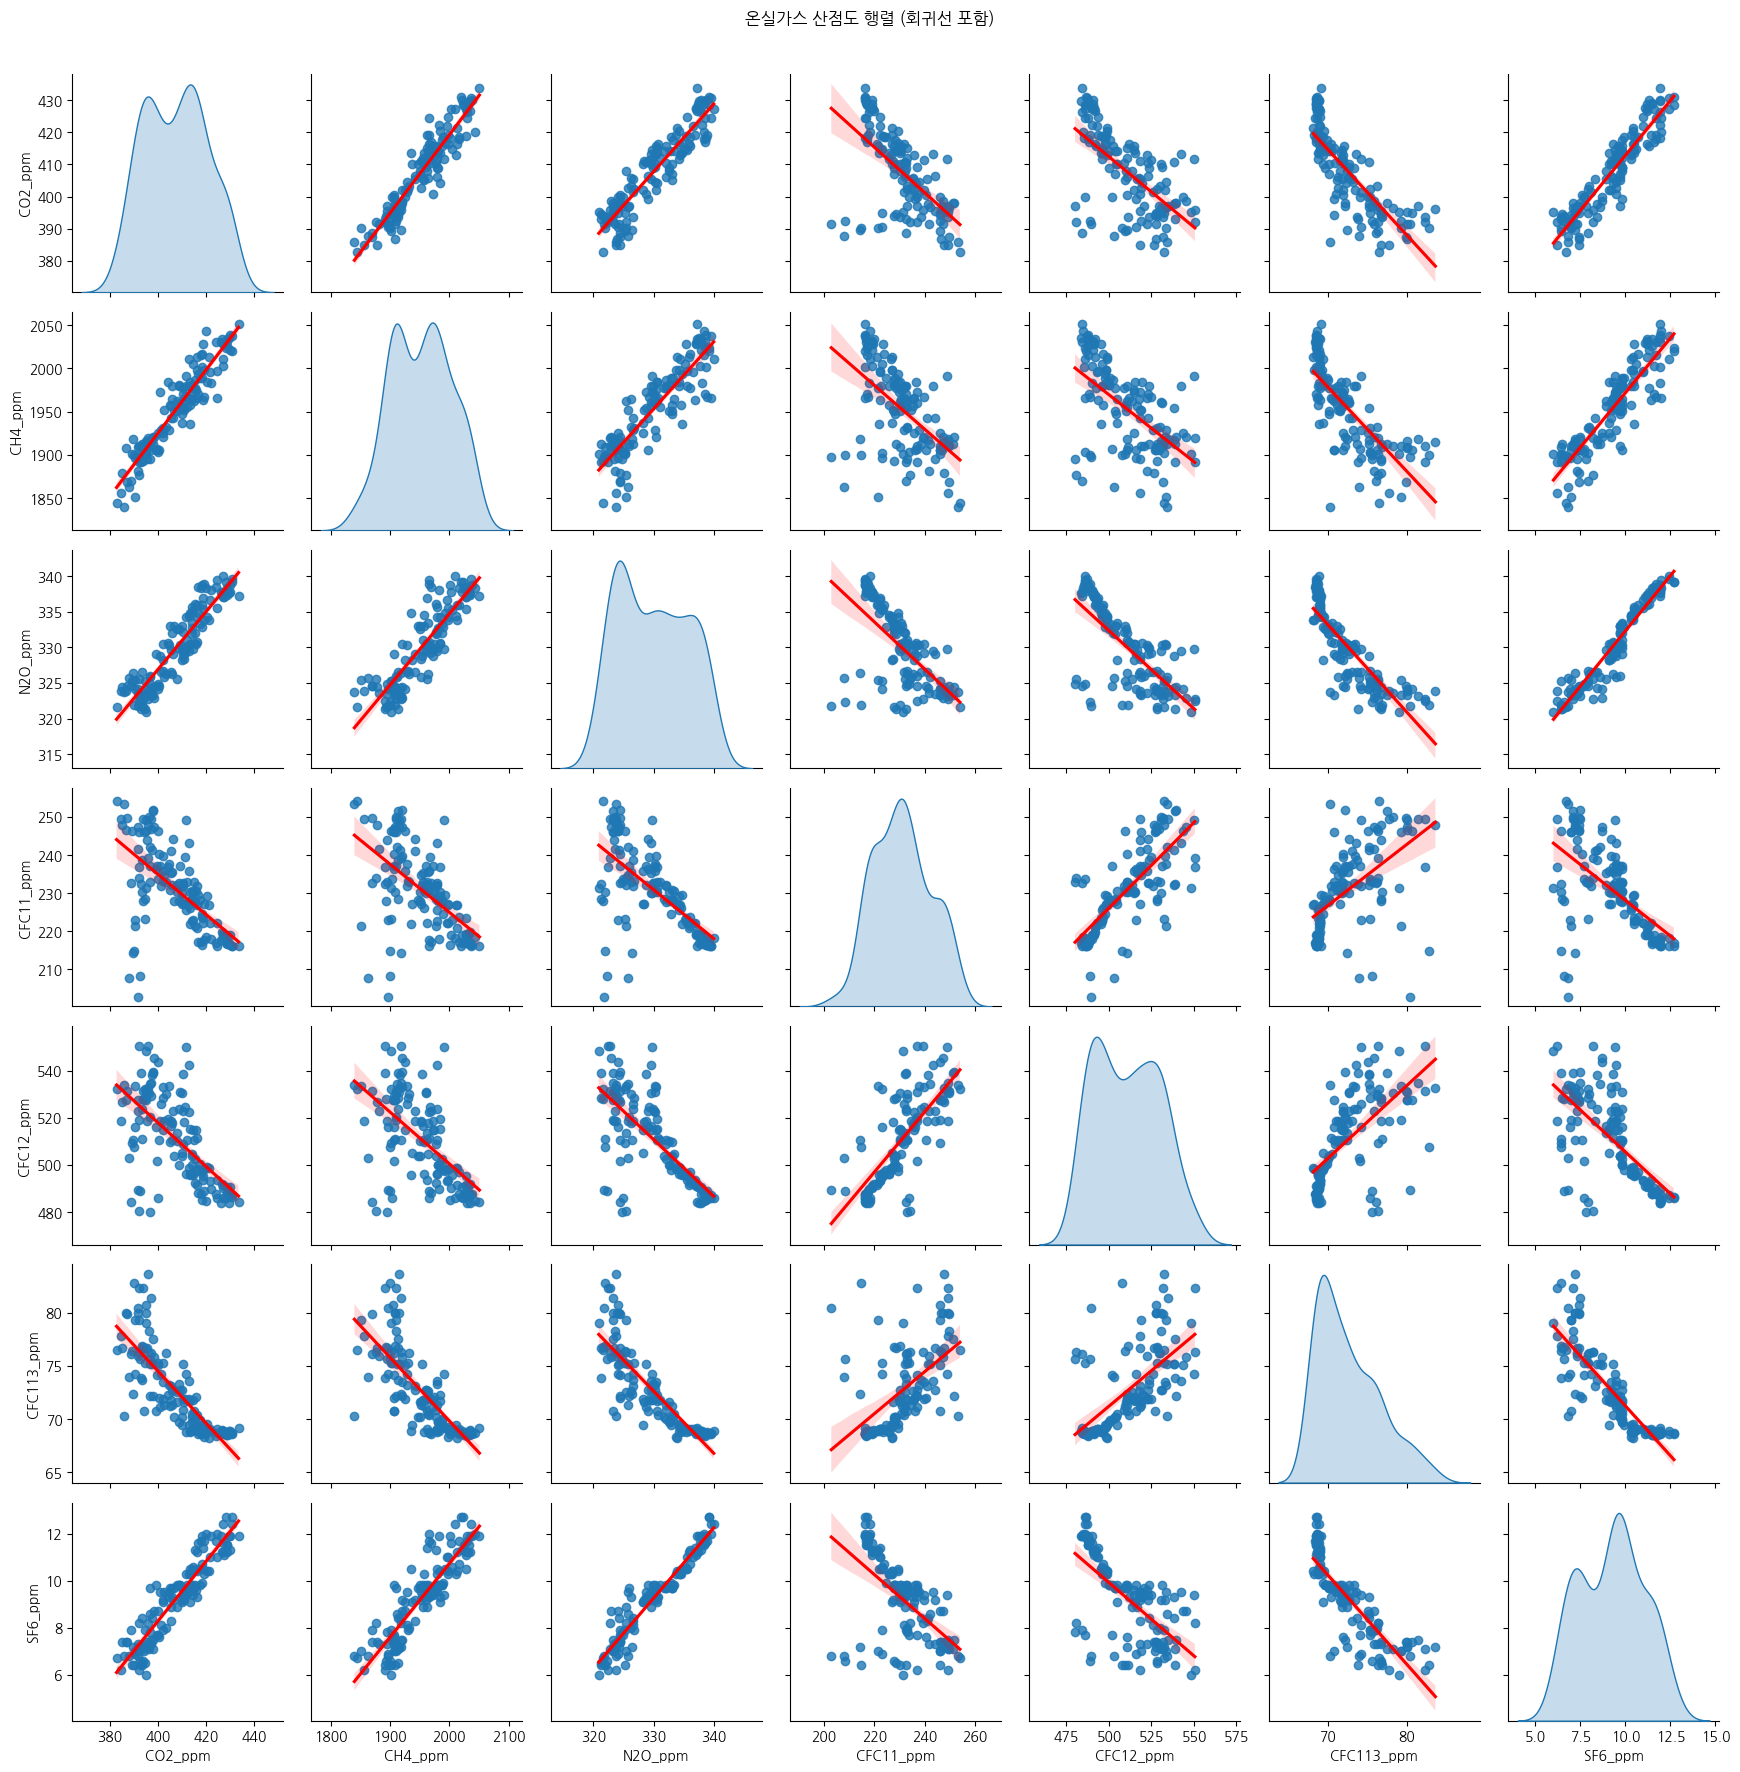

In [ ]:
# 온실가스 산점도 행렬 + 회귀선 — seaborn pairplot()
sns.pairplot(df_ghgs2.dropna(), diag_kind='kde', kind='reg', plot_kws={'line_kws': {'color': 'red'}})
plt.suptitle('온실가스 산점도 행렬 (회귀선 포함)', y=1.01)
plt.tight_layout()
plt.show()

---

## 핵심 요약

| 그래프 | 데이터 유형 | 분석 목적 | 주요 함수 |
|---|---|---|---|
| 히스토그램 | 연속형 | 분포 확인 | `.plot.hist()`, `plt.hist()`, `sns.histplot()` |
| 막대그래프 | 범주형 | 빈도·크기 비교 | `.plot.bar()`, `sns.countplot()` |
| 파이차트 | 범주형 | 비율 파악 | `.plot.pie()`, `plt.pie()` |
| 선 그래프 | 시계열 | 변화 추이 | `.plot.line()`, `plt.plot()`, `sns.lineplot()` |
| 상자 도형 | 연속형 (그룹별) | 분포·이상치 비교 | `.boxplot()`, `sns.boxplot()` |
| 산점도 | 연속형 2변수 | 두 변수 관계 | `.plot.scatter()`, `plt.scatter()`, `sns.scatterplot()` |
| 히트맵 | 상관계수 행렬 | 변수 간 관계 요약 | `sns.heatmap()` |
| 산점도 행렬 | 다변수 | 전체 관계 탐색 | `.scatter_matrix()`, `sns.pairplot()` |